In [31]:
# Importazione delle librerie necessarie
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder

# Impostazioni grafiche per visualizzare i grafici direttamente nel notebook
sns.set_theme(style="whitegrid")

In [32]:
# Caricamento del dataset 
df = pd.read_csv('cupid_dataset.csv')

print(f"Dimensioni del dataset: {df.shape[0]} righe e {df.shape[1]} colonne\n")

print("Informazioni sulle variabili:")
df.info()


Dimensioni del dataset: 100000 righe e 30 colonne

Informazioni sulle variabili:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 30 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   pair_id                        100000 non-null  int64  
 1   a_age                          99999 non-null   float64
 2   a_education                    100000 non-null  int64  
 3   a_location                     100000 non-null  object 
 4   a_career_field                 100000 non-null  object 
 5   a_career_ambition              100000 non-null  float64
 6   a_openness                     100000 non-null  float64
 7   a_extraversion                 100000 non-null  float64
 8   a_agreeableness                100000 non-null  float64
 9   a_conscientiousness            100000 non-null  float64
 10  a_chronotype                   100000 non-null  float64
 11  a_spontanei

,Conteggio NaN
a_age,1
a_emotional_expressiveness,1
b_love_language,1


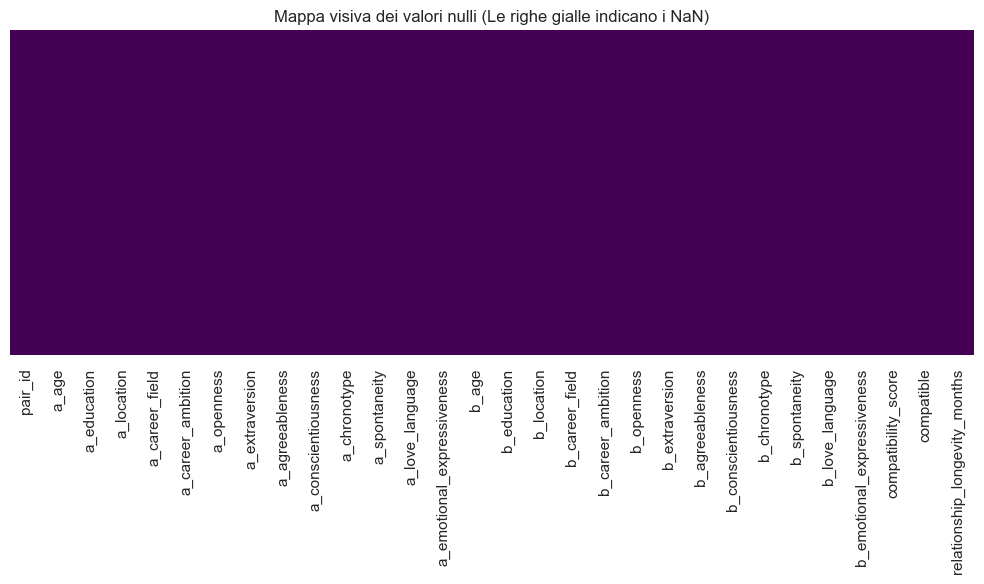

In [33]:
# Calcolo esatto e in percentuale dei valori nulli
valori_nulli = df.isnull().sum()
colonne_con_nulli = valori_nulli[valori_nulli > 0]

if not colonne_con_nulli.empty:
    df_nulli = pd.DataFrame({
        'Conteggio NaN': colonne_con_nulli,
        
    })
    display(df_nulli)
else:
    print("Nessun valore nullo trovato nel dataset!")

# Mappa visiva dei valori nulli
plt.figure(figsize=(10, 6))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis', yticklabels=False)
plt.title('Mappa visiva dei valori nulli (Le righe gialle indicano i NaN)')
plt.tight_layout()
plt.show()

In [34]:
print("Statistiche descrittive (Variabili Numeriche):")
display(df.describe().round(2))

print("\nStatistiche descrittive (Variabili Categoriche/Testuali):")
display(df.describe(include=['object', 'category']))

Statistiche descrittive (Variabili Numeriche):


,pair_id,a_age,a_education,a_career_ambition,a_openness,a_extraversion,a_agreeableness,a_conscientiousness,a_chronotype,a_spontaneity,...,b_openness,b_extraversion,b_agreeableness,b_conscientiousness,b_chronotype,b_spontaneity,b_emotional_expressiveness,compatibility_score,compatible,relationship_longevity_months
count,100000.00,99999.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,...,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00
mean,50000.50,36.56,2.95,0.50,0.50,0.50,0.50,0.50,0.50,0.50,...,0.50,0.50,0.50,0.50,0.50,0.50,0.50,63.12,0.43,68.91
std,28867.66,10.95,1.12,0.17,0.22,0.22,0.22,0.22,0.22,0.23,...,0.22,0.22,0.22,0.22,0.22,0.23,0.23,10.71,0.49,21.33
min,1.00,18.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,16.50,0.00,0.00
25%,25000.75,27.00,2.00,0.37,0.33,0.33,0.33,0.32,0.33,0.33,...,0.33,0.33,0.33,0.33,0.33,0.32,0.33,55.90,0.00,54.00
50%,50000.50,37.00,3.00,0.50,0.50,0.50,0.50,0.50,0.50,0.50,...,0.50,0.50,0.50,0.50,0.50,0.50,0.50,63.00,0.00,69.00
75%,75000.25,46.00,4.00,0.62,0.67,0.67,0.68,0.67,0.67,0.67,...,0.67,0.67,0.67,0.67,0.68,0.68,0.67,70.30,1.00,83.00
max,100000.00,55.00,5.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,...,1.00,1.00,1.00,1.00,1.00,1.00,1.00,100.00,1.00,120.00



Statistiche descrittive (Variabili Categoriche/Testuali):


,a_location,a_career_field,a_love_language,b_location,b_career_field,b_love_language
count,100000,100000,100000,100000,100000,99999
unique,3,10,5,3,10,5
top,Urban,Finance,Words of Affirmation,Urban,Marketing,Receiving Gifts
freq,49832,10169,20160,49837,10124,20276


In [35]:
# CONVERSIONE DEL TESTO IN NUMERI
# Trova tutte le colonne che contengono testo e convertile in codici numerici
for col in df.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))

# DEFINIZIONE DEL TARGET (y) E DELLE FEATURE (X)
colonna_target = 'compatibility_score'  # Assicurati che il nome sia esatto
colonne_da_escludere = ['pair_id', colonna_target, 'relationship_longevity_months', 'compatible']
X = df.drop(columns=[col for col in colonne_da_escludere if col in df.columns])
y = df[colonna_target]

# ADDESTRAMENTO DEL MODELLO
print("Calcolo in corso...\n")

# RANDOM FOREST
rf = RandomForestRegressor(
    n_estimators=100, 
    random_state=42, 
    n_jobs=-1,         
    max_depth=10       
)
rf.fit(X, y)

# VERIFICA DELLA CORRELAZIONE
print("\n--- CORRELAZIONE DELLE FEATURE CON IL PUNTEGGIO FINALE ---")
correlation_matrix = df.corr()
# Mostra quali feature crescono o decrescono al crescere del punteggio
print(correlation_matrix[colonna_target].sort_values(ascending=False))

print("\n\n\n")
# ESTRAZIONE DELL'IMPORTANZA
importances = pd.Series(rf.feature_importances_, index=X.columns)
print("--- IMPORTANZA DELLE FEATURE (Da 0 a 1) ---")
print(importances.sort_values(ascending=False))

# Mostra quali feature crescono o decrescono al crescere del punteggio
print(correlation_matrix[colonna_target].sort_values(ascending=False))

Calcolo in corso...


--- CORRELAZIONE DELLE FEATURE CON IL PUNTEGGIO FINALE ---
compatibility_score              1.000000
compatible                       0.794533
relationship_longevity_months    0.549572
a_career_field                   0.018011
b_location                       0.017494
a_location                       0.017028
b_career_field                   0.012989
a_agreeableness                  0.006365
b_spontaneity                    0.003331
a_openness                       0.002986
a_extraversion                   0.002642
a_chronotype                     0.001986
b_extraversion                   0.000922
a_education                      0.000770
a_career_ambition                0.000582
a_age                            0.000578
a_conscientiousness              0.000264
a_emotional_expressiveness      -0.000123
b_conscientiousness             -0.000761
b_love_language                 -0.001469
b_career_ambition               -0.001590
pair_id                         -0.00